Z-score Anomaly Detection

In [2]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Generate sample data (temperatures)
np.random.seed(0)
data = np.random.normal(25, 5, 100)  # Mean=25, Standard Deviation=5

# Calculate Z-scores for each data point
z_scores = np.abs(stats.zscore(data))

# Define a threshold for anomaly detection (e.g., Z-score > 2.5)
threshold = 2.5

# Identify anomalies based on the threshold
anomalies = np.where(z_scores > threshold)

# Output the anomalies
print("Data Points:", data)
print("Z-Scores:", z_scores)
print("Anomalies:", anomalies[0])

Data Points: [33.82026173 27.00078604 29.89368992 36.204466   34.33778995 20.1136106
 29.75044209 24.24321396 24.48390574 27.05299251 25.72021786 32.27136753
 28.80518863 25.60837508 27.21931616 26.66837164 32.47039537 23.97420868
 26.56533851 20.7295213  12.23505092 28.26809298 29.32218099 21.2891749
 36.34877312 17.72817163 25.22879259 24.06408075 32.66389607 32.34679385
 25.77473713 26.8908126  20.56107126 15.09601766 23.26043925 25.78174485
 31.1514534  31.01189924 23.06336591 23.48848625 19.75723517 17.89991031
 16.46864905 34.75387698 22.45173909 22.80962849 18.7360232  28.88745178
 16.93051076 23.9362986  20.52266719 26.93451249 22.44597431 19.09683908
 24.85908886 27.14165935 25.33258611 26.51235949 21.82838953 23.18629417
 21.63769776 23.20223419 20.93426859 16.36858699 25.88713071 22.99109532
 16.84900827 27.31391128 20.46350818 25.25972698 28.64545281 25.64491455
 30.69700342 18.8258709  27.01170821 21.57594955 20.64601425 22.10575168
 23.44223734 25.28082671 19.1742508  29.

(array([ 1.,  5.,  7., 13., 17., 18., 16., 11.,  7.,  5.]),
 array([12.23505092, 14.64642314, 17.05779536, 19.46916758, 21.8805398 ,
        24.29191202, 26.70328424, 29.11465646, 31.52602868, 33.9374009 ,
        36.34877312]),
 <BarContainer object of 10 artists>)

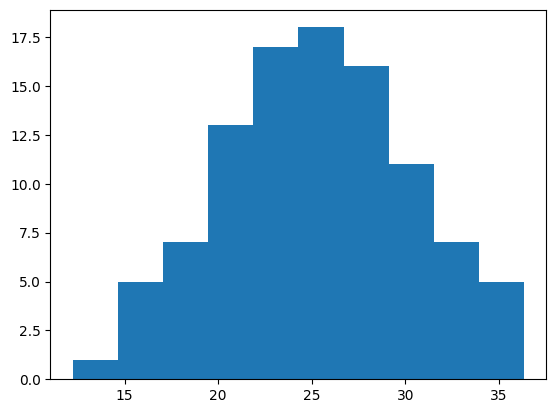

In [3]:
plt.hist(data)

Custom Rule-Based Anomaly Detection

In [4]:
# Sample data: Customer support call durations (in minutes)
call_durations = [12, 8, 10, 25, 7, 30, 9, 8, 10, 26, 8, 11]

# Define a custom rule: Flag calls with duration > 20 minutes as anomalies
threshold_duration = 20

# Identify anomalies based on the custom rule
anomalies = [duration for duration in call_durations if duration > threshold_duration]

# Output the anomalies
print("Call Durations:", call_durations)
print("Anomalies:", anomalies)

Call Durations: [12, 8, 10, 25, 7, 30, 9, 8, 10, 26, 8, 11]
Anomalies: [25, 30, 26]


In [5]:
from google.colab import userdata
import os
os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')


Practical Example: Anomaly Detection in Temperature Sensors

Let’s illustrate the application of ChatGPT in anomaly detection with a practical example.

In [6]:
import requests
import os

# Set your Gemini API key here
api_key = "YOUR_GEMINI_API_KEY"
os.environ["API_KEY"] = api_key

# Temperature readings data with anomalies
temperature_data = [
    {"temperature": 36.5, "location": "Sensor A", "timestamp": "2023-03-15 14:30:00"},
    {"temperature": 36.2, "location": "Sensor A", "timestamp": "2023-03-15 14:35:00"},
    {"temperature": 38.0, "location": "Sensor A", "timestamp": "2023-03-15 14:40:00"},  # Anomaly
    {"temperature": 36.8, "location": "Sensor A", "timestamp": "2023-03-15 14:45:00"},
    {"temperature": 36.3, "location": "Sensor A", "timestamp": "2023-03-15 14:50:00"},
]

# Configure the request headers and base URL for the Gemini API
headers = {
    "Authorization": f"Bearer {os.environ['API_KEY']}",
    "Content-Type": "application/json"
}

# Base URL for Gemini API
base_url = "https://api.gemini-service.com/v1/completions"

# Iterate through temperature data and ask Gemini to find anomalies and justify
for data in temperature_data:
    prompt = f"Analyze the temperature reading of {data['temperature']}°C at {data['location']} at {data['timestamp']} and justify if it is an anomaly."

    data_payload = {
        "model": "gemini-1.5-pro-latest",  # Replace with the actual model name if different
        "prompt": prompt,
        "max_tokens": 50
    }

    response = requests.post(base_url, headers=headers, json=data_payload)

    if response.status_code == 200:
        justification = response.json()['choices'][0]['text'].strip()
        print(f"Temperature reading of {data['temperature']}°C at {data['location']} at {data['timestamp']}:")
        print(justification)
    else:
        print(f"Failed to get a response for the temperature reading of {data['temperature']}°C at {data['location']} at {data['timestamp']}")

ConnectionError: HTTPSConnectionPool(host='api.gemini-service.com', port=443): Max retries exceeded with url: /v1/completions (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7f2971c19180>: Failed to resolve 'api.gemini-service.com' ([Errno -2] Name or service not known)"))

# Challenge

In [7]:
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [8]:
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
 80% 53.0M/66.0M [00:00<00:00, 176MB/s]
100% 66.0M/66.0M [00:00<00:00, 173MB/s]


In [9]:
! unzip "creditcardfraud.zip"

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [10]:
import pandas as pd

In [11]:
df=pd.read_csv("creditcardfraud.zip")

In [12]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [13]:
# prompt: Normalize the features Amount and V1 with StandardScaler. Use the method fit.transform on the requested columns.

from sklearn.preprocessing import StandardScaler

# Select the columns to normalize
cols_to_normalize = ['Amount', 'V1']

# Create a StandardScaler object
scaler = StandardScaler()

# Fit and transform the selected columns
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])


In [18]:
# prompt: Implement a simple Gaussian model on a mormalized features.
# Flag transactions with very low probability values as potential anomalies.

import numpy as np
from scipy.stats import multivariate_normal

# Select the normalized features for the Gaussian model
features = df[['Amount', 'V1']]

# Calculate the mean and covariance of the normalized features
mean = np.mean(features, axis=0)
covariance = np.cov(features.T)

# Create a Gaussian model
gaussian_model = multivariate_normal(mean=mean, cov=covariance)

# Calculate probability values for each transaction
probability_values = gaussian_model.pdf(features)

# Define a threshold for anomaly detection (e.g., probability < 0.001)
threshold = 0.001

# Flag transactions with very low probability values as potential anomalies
anomalies = features[probability_values < threshold]

# Print the number of anomalies detected
print(f"Number of anomalies detected: {len(anomalies)}")

# Display some of the detected anomalies
print("Some detected anomalies:")
print(anomalies.head())


Number of anomalies detected: 7140
Some detected anomalies:
        Amount        V1
51    5.255886 -0.513061
89    4.212665 -0.394800
140   3.323411 -2.604736
150   3.395736 -0.837301
164  14.951604 -3.110875


In [17]:
# prompt: help to draft a brief summary of findings (anomalies)

# Assuming 'anomalies' is the array of indices of detected anomalies
if len(anomalies[0]) > 0:
  print(f"Found {len(anomalies[0])} potential anomalies in the dataset.")
  print("These anomalies might indicate fraudulent transactions or unusual patterns in the data.")
  print("Further investigation is needed to confirm the nature of these anomalies.")
else:
  print("No anomalies were detected in the dataset.")


Found 7140 potential anomalies in the dataset.
These anomalies might indicate fraudulent transactions or unusual patterns in the data.
Further investigation is needed to confirm the nature of these anomalies.


In [20]:
from scipy.stats import norm # import the norm function from scipy.stats

In [22]:
df['NormalizedAmount'] = scaler.fit_transform(df[['Amount']])
feature = 'NormalizedAmount'
df['prob'] = norm.pdf(df[feature], df[feature].mean(), df[feature].std())
threshold = 0.01  # Define your threshold
anomalies = df[df['prob'] < threshold]
print(f"Number of anomalies detected: {len(anomalies)}")
print("Some detected anomalies:")
print(anomalies.head())

Number of anomalies detected: 4800
Some detected anomalies:
      Time        V1         V2        V3        V4        V5        V6  \
51    36.0 -0.513061  -0.985978 -0.038039  3.710061 -6.631951  5.122103   
89    59.0 -0.394800  -4.146007 -0.932038  0.027094 -1.698307  0.460188   
140   87.0 -2.604736   1.897022 -3.458034 -1.277543 -5.517758  2.098366   
150   93.0 -0.837301  -0.479831  1.613630  2.997979 -3.803788  5.051812   
164  103.0 -3.110875 -12.114213 -5.694973  3.294389 -1.413792  4.776000   

           V7        V8        V9  ...       V23       V24       V25  \
51   4.371691 -2.006868 -0.278736  ...  0.969719  0.019445  0.570923   
89   0.737344 -0.314216 -0.842673  ... -1.134769 -0.654958  0.098386   
140  3.329603  1.250966  0.271501  ... -0.555900 -0.761660  0.066611   
150  3.315254 -0.303785  0.671395  ... -0.405779 -1.268700  0.494090   
164  4.808426 -0.228197 -0.525896  ... -3.553381  1.215279 -0.406073   

          V26       V27       V28     Amount  Class  Nor